# Generating ssh-keys

As our lives become more "on-line" and as our lives become as dependent on online services as they once were on electric or gas companies, the security of these connections has become much more important. Sometimes to our inconvenience. 

Passwords are considered too vulnerable to hackers or social engineers and a common method to remove their need is to use cyptographic keys.

### What are public/private key pairs?
Imagine a time of sail ships and horse based couriers. If a country wanted to enable safe communication between its distant diplomats, here is one way they could do it.

Give them a set of open locks, with no keys. The keys remain in the capital city. When remote diplomats want to send back secrets, they lock the courier box with their lock. No one can open this lock, not even the diplomats themselves. The box is sent back to the capital, where the credentialed official uses their key to open the box and retreieve its contents.

Notice that secure communication was enabled by two items: the open lock, which was completely public and the key, which was very private. 

### How to generate public/private keys

We will authenticate ourselves, not with passwords, but with a public/private key pair. We will generate a pair using the `ssh` utility. The private key will remain on our laptop, very private and never to be shared with anyone. The public key will be uploaded to remove services.

Once a connection is initiated, the remote service will send the public key back to us, which will be compared to the private key. If the two match, our identity will have been established. 

Warning, if you have already generated keys, you have the option of using them or giving a different name to the keys generated below. Please consult online resources for details.

Let's generate a key pair:

```bash
ssh-keygen -t ed25519
```

This command will ask for the location where your key will be location and the passphrase. For our purpose, we will leave both of them blank (just press "Enter" a few times).

```bash
Generating public/private ed25519 key pair.
Enter file in which to save the key (/home/ubuntu/.ssh/id_ed25519): 
Enter passphrase for "/home/ubuntu/.ssh/id_ed25519" (empty for no passphrase): 
Enter same passphrase again: 
Your identification has been saved in /home/ubuntu/.ssh/id_ed25519
Your public key has been saved in /home/ubuntu/.ssh/id_ed25519.pub
The key fingerprint is:
SHA256:bNXUMN4pk3KeKU6KMOp/ciY2XXrEGAXKUAjWYIjkzc8 ubuntu@chicagoes1
The key's randomart image is:
+--[ED25519 256]--+
|=*+o. ..    +o   |
|* ++ .  .  + +.. |
| . oo  .  o B o  |
|    o .. . + =   |
|    oE +S o +    |
|   . o.o++ .     |
|  .  ..+. .      |
| .  = * .        |
|  .o.B .         |
+----[SHA256]-----+
```

Once you have generated the key pair, you will see it in your home directory's `.ssh` directory:

```bash
ls ~/.ssh
authorized_keys  id_ed25519  id_ed25519.pub
```
(note that in Windows, you can view the files via `dir .ssh` command

The public key looks like this:
```bash
cat .ssh/id_ed25519.pub 
ssh-ed25519 AAAAC3NzaC1lZDI1NTE5AAAAIDLPKHUBS5TRL/w40Xddb3QmgP6lw09SdG1PKR1VojSh ubuntu@chicagoes1
```

The `.pub` file is the public key and should be uploaded to the remote server or services.

### Logging on to a remote linux server witih ssh key instead of password

The most common use of ssh key pairs is to log on to a remote server without using a password. You can set up the remote machine by uploading the public key via `scp` (similar to the `cp` command, but across machines):

Laptop:
```bash
scp .ssh/id_ed25519.pub YOUR_USER_NAME@123.456.78.90:~/. 
```

The command above will upload the public key to your home directory on the remote server. From there, you need to append the contents of this file to `~/.ssh/authorized_keys`:

Remote machine:
```bash
mkdir .ssh
cat id_ed25519.pub >> ~/.ssh/authorized_keys
```

If your computer has the `ssh-copy-id` utility, you can also use it:  
Laptop:
```bash
ssh-copy-id -i ~/.ssh/id_ed25519.pub YOUR_USER_NAME@123.456.78.90
```

### Connecting to GitHub via ssh keys
Unfortunately, GitHub no longer allows password based logins. If you wish to connect your linux virtual machine or remote server to GitHub, you need to use ssh keys to do so.

Click on the "Code" button and switch from the "HTTPS" tab to "SSH" tab. There you will see instructions on how to add your public ssh key to GitHub.

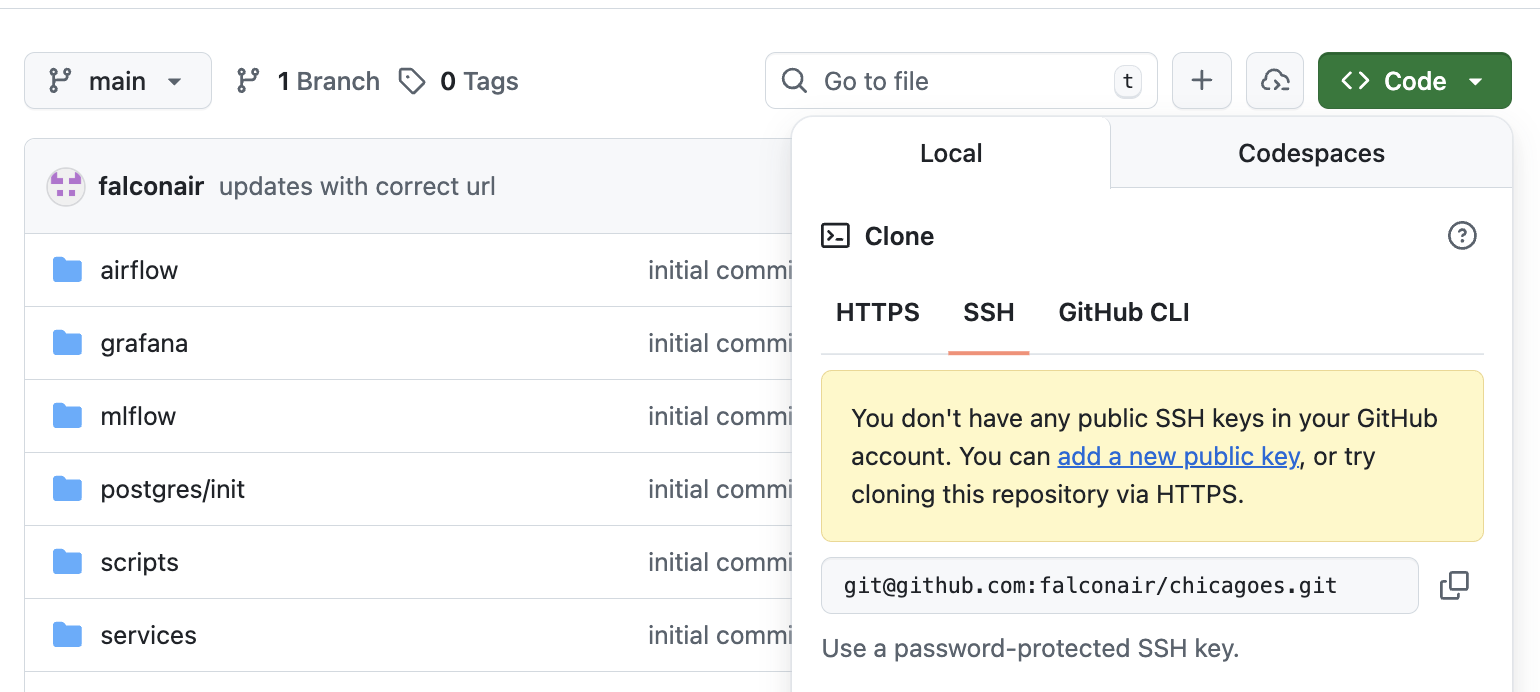

Note that the page to access ssh keys is also accessible via https://github.com/settings/ssh/ (it isn't clear to the author why "SSH and GPG keys" doesn't show up under "Settings")

Click on "add a new public key" and paste the contents of your `.pub` key:

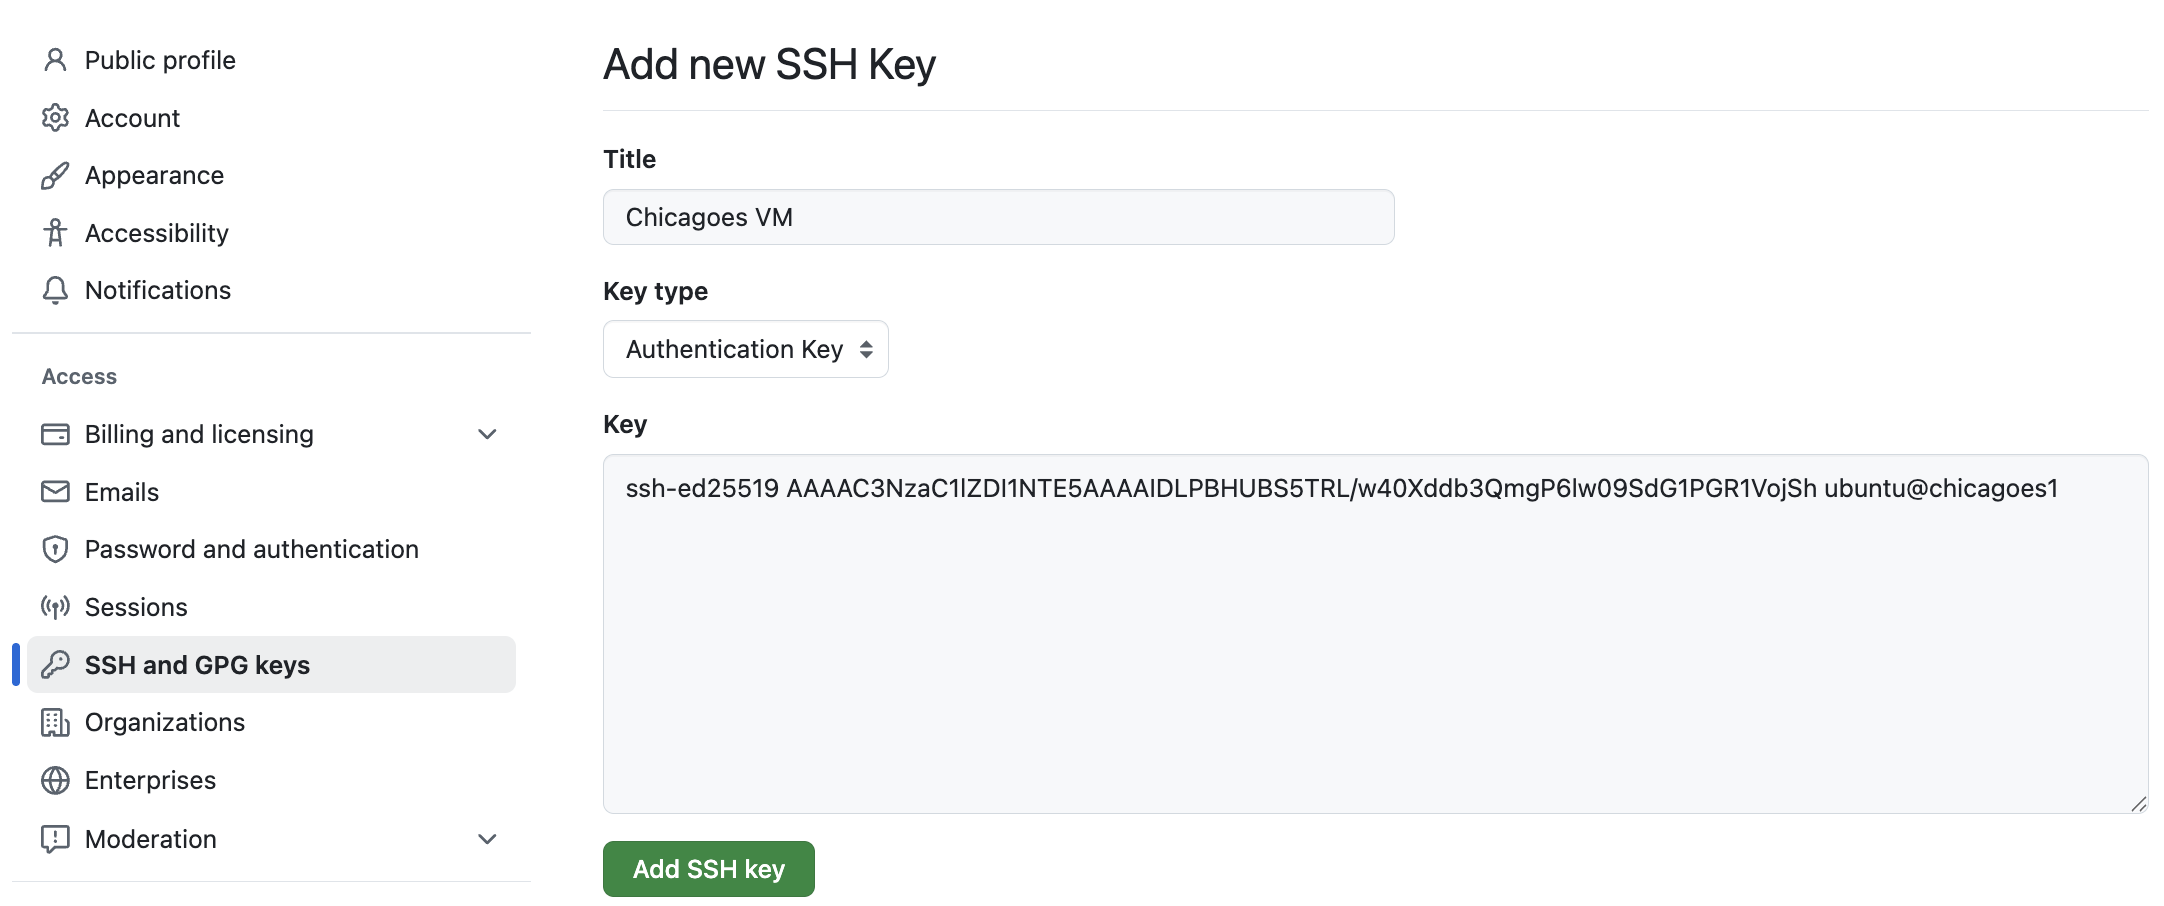

Once you have done so, you should be able to clone a remote repository. 

**Common mistake**: It is very common to clone via the `git clone https://...` command, which will result in Git asking you for user/password and rejecting your attempt with the following message:
`Remote: Invalid username or token. Password authentication is not supported for Git operations.`

You must use `git clone git://...` (notice the `git` instead of `https`)

### Be aware of vulnerabilities

Take a step back and look at the decisions we have made and their tradeoffs. 

**Password vs ssh key** We are no longer using passwords! However, the public key is now essentially your password. You will not get annoyed and used a very simple password, such as "1234" or a very common one, such as "password". However, the ssh key is still sitting on your laptop. If your laptop is compromised, so are your connections.

**Use a passphrase** A simple solution to mitigate the leak of your ssh private key is to additionally use passphrase. Recall that we had the option of using a passphrase when creating the key pair. This essentially brings back passwords, _on top of ssh keys_. 

**Single key for multiple services** Also note that we used the same key for Github as well as to log on to a remote machine. If our private key is compromised, and if we are not using a passphrase, all remote services that use this key are now also compromised. Ideally, we should create different keys for different services. This is not done often enough in reality (the author is also guilty of this). If multiple keys are generate for different services, it is useful to create a configuration file mapping services to keys as such:

```bash
#~/.ssh/config
# Configuration for Service A
Host serviceA
  HostName service-a.example.com
  User your_username_on_serviceA
  IdentityFile ~/.ssh/serviceA_key
  IdentitiesOnly yes

# Configuration for Service B
Host serviceB
  HostName service-b.example.com
  User your_username_on_serviceB
  IdentityFile ~/.ssh/serviceB_key
  IdentitiesOnly yes
```

Keys for multiple services can be generated in the following manner:
```bash
ssh-keygen -t ed25519 -C "user@serviceA" -f ~/.ssh/serviceA_key
ssh-keygen -t ed25519 -C "user@serviceB" -f ~/.ssh/serviceB_key
```